# Imports and utility

In [1]:

!pip install -q --upgrade keras-hub
#d8f53b61969adf7ee621c216f680b707
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import keras_hub
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
                                     BatchNormalization, Activation, GlobalAveragePooling2D)
from tensorflow.keras.applications import VGG16, VGG19, ResNet50, ResNet152, EfficientNetB0, DenseNet121, InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, LearningRateScheduler, ModelCheckpoint
from tensorflow.keras import optimizers
import keras_hub

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   # 0 = todo, 1 = INFO, 2 = WARNING, 3 = ERROR
tf.get_logger().setLevel('ERROR')

train_dir = '/kaggle/input/knee-osteoarthritis-dataset-with-severity/train'
val_dir = '/kaggle/input/knee-osteoarthritis-dataset-with-severity/val'
test_dir = '/kaggle/input/knee-osteoarthritis-dataset-with-severity/test'
auto_test = '/kaggle/input/knee-osteoarthritis-dataset-with-severity/auto_test'
cat_dir = '/kaggle/input/cat-knee/clean'

IMG_SIZE = (224, 224)
BATCH_SIZE = 8
SEED = 66


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 792.1/792.1 kB 11.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.18.1 requires keras-hub==0.18.1, but you have keras-hub 0.20.0 which is incompatible.


In [2]:
import pandas as pd
import os

def create_dataframe_from_directory(base_dir, regression=False):
    data = []
    for label_str in sorted(os.listdir(base_dir)):
        label_path = os.path.join(base_dir, label_str)
        if not os.path.isdir(label_path):
            continue
        label = float(label_str) if regression else label_str
        for fname in os.listdir(label_path):
            data.append({
                'filename': os.path.join(label_str, fname),  # ruta relativa
                'label': label  # KL debe ser numérico para regresión
            })
    return pd.DataFrame(data)

In [3]:
from sklearn.metrics import mean_absolute_error, accuracy_score
import numpy as np
import tensorflow as tf

class CatValidationCallback(tf.keras.callbacks.Callback):
    def __init__(self, cat_generator, regresion=False, filepath='best_model_cat.keras'):
        super().__init__()
        self.cat_generator = cat_generator
        self.epoch_metrics = []
        self.regresion = regresion
        self.filepath = filepath
        # Inicializamos best_score y best_loss
        if regresion:
            self.best_score = 0.0    # queremos maximizar accuracy
            self.best_loss  = np.inf # y minimizar MAE
        else:
            self.best_score = 0.0    # queremos maximizar accuracy
            self.best_loss  = np.inf # y minimizar categorical loss

    def on_epoch_end(self, epoch, logs=None):
        # Predicciones
        preds = self.model.predict(self.cat_generator, verbose=0)

        if self.regresion:
            # Regresión: calculamos MAE + accuracy sobre clases redondeadas
            y_pred = preds.flatten()
            y_true = self.cat_generator.labels
            loss = mean_absolute_error(y_true, y_pred)
            y_pred_class = np.clip(np.round(y_pred), 0, 4).astype(int)
            y_true_class = np.clip(np.round(y_true), 0, 4).astype(int)
            acc = accuracy_score(y_true_class, y_pred_class)
            score = acc
        else:
            # Clasificación: evalúa el loss y la accuracy
            loss, acc = self.model.evaluate(self.cat_generator, verbose=0)
            preds_class = np.argmax(preds, axis=1)
            y_true = self.cat_generator.classes
            # para consistency, recalculamos acc con sklearn
            acc = accuracy_score(y_true, preds_class)
            score = acc

        # Guardar métricas
        self.epoch_metrics.append({
            'epoch': epoch + 1,
            'val_cat_loss': loss,
            'val_cat_accuracy': acc
        })

        # Mostrar por consola
        tag = "MAE" if self.regresion else "Loss"
        print(f"🐾 [Cat Val] {tag}: {loss:.4f} | Accuracy: {acc:.4f}")

        # Comprobamos mejora: primero por score, si empate por loss
        improved = False
        if score > self.best_score:
            improved = True
        elif score == self.best_score and loss < self.best_loss:
            improved = True

        # Si mejoró, guardamos modelo y actualizamos referencias
        if improved:
            self.best_score = score
            self.best_loss  = loss
            self.model.save(self.filepath)
            print(f"📦 Modelo mejorado guardado en {self.filepath}")


In [4]:
from tensorflow.keras.callbacks import ModelCheckpoint

def get_callbacks(regression=False, cat_gen=None, finetuning=False):
  if cat_gen:
      cat_val_cb = CatValidationCallback(cat_gen, regresion=regression)
  if finetuning:
      earlystopping = 5
      patience = 3
  else:
      earlystopping = 10
      patience = 3
      

  checkpoint_cb = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_accuracy',         # nombre de la métrica a monitorizar
    mode='max',                     # porque buscamos la mayor precisión
    save_best_only=True,
    save_weights_only=False,
    verbose=1
  )
  checkpoint_cb_reg = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    save_weights_only=False,
    verbose=1
  )
  if regression:
    callbacks = [
        EarlyStopping(patience=earlystopping, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.5, patience=patience, verbose=1),
        checkpoint_cb_reg
    ]
  else:
    callbacks = [
        EarlyStopping(patience=earlystopping, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.5, patience=patience, verbose=1),
        checkpoint_cb
    ]
  if cat_gen:
      callbacks.append(cat_val_cb)
  return callbacks


In [5]:
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def _get_label_map(y_true, y_pred, generator=None, default_prefix='KL'):
    """
    Genera label_map automáticamente.
    - Si el generador tiene class_indices (clasificación Keras), los usa.
    - Si no, extrae las clases únicas de y_true y y_pred.
    - Si todo falla, crea labels 'KL 0', 'KL 1', ..., según número de clases.
    """
    # Caso Keras classification_generator
    if generator is not None and hasattr(generator, 'class_indices'):
        # Ordenar por índice
        sorted_items = sorted(generator.class_indices.items(), key=lambda x: x[1])
        return [name for name, _ in sorted_items]
    
    # Extraer clases únicas
    classes = np.unique(np.concatenate((y_true, y_pred)))
    # Si son enteros consecutivos desde 0 a n-1
    if np.array_equal(classes, np.arange(len(classes))):
        return [f'{default_prefix} {i}' for i in classes]
    # En caso de etiquetas no enteras o desordenadas
    return [str(c) for c in classes]

def evaluate_classification(y_true, y_pred, label_map=None, digits=4, title_suffix=''):
    """
    Reporte de clasificación + matriz de confusión.
    """
    if label_map is None:
        label_map = _get_label_map(y_true, y_pred)
    # Reporte
    print(classification_report(
        y_true, y_pred,
        target_names=label_map,
        digits=digits
    ))
    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=label_map, yticklabels=label_map
    )
    plt.xlabel('Predicción')
    plt.ylabel('Etiqueta verdadera')
    if title_suffix:
        plt.title(title_suffix)
    plt.show()

def evaluate_model(model, regression, generator, label_map=None, digits=4):
    """
    Elige el modo de evaluación y asegura que label_map siempre se resuelva.
    """
    # Predicciones crudas
    preds = model.predict(generator)
    
    if regression:
        # Convertir a clases
        if hasattr(generator, 'labels'):
            y_true_cont = np.array(generator.labels).flatten()
        else:
            y_true_cont = np.array(generator.classes).flatten()
        y_pred_cont = np.array(preds).flatten()
        
        # MAE
        mae = mean_absolute_error(y_true_cont, y_pred_cont)
        print(f"Mean Absolute Error (MAE): {mae:.{digits}f}\n")
        plt.figure(figsize=(6,6))
        # Dispersión
        plt.scatter(y_pred_cont, y_true_cont, alpha=0.5)
        # Línea de identidad
        mn = min(y_true_cont.min(), y_pred_cont.min())
        mx = max(y_true_cont.max(), y_pred_cont.max())
        plt.plot([mn, mx], [mn, mx], 'r--', linewidth=1)
        # Etiquetas
        plt.xlabel("Predicción (decimal)")
        plt.ylabel("Valor verdadero")
        plt.title("Scatter: Predicción vs Valor verdadero")
        plt.grid(True)
        plt.show()

        y_true_class = np.clip(np.round(y_true_cont).astype(int), 0, None)
        y_pred_class = np.clip(np.round(y_pred_cont).astype(int), 0, None)
        # Obtener label_map adaptado al rango observado
        if label_map is None:
            max_label = max(y_true_class.max(), y_pred_class.max())
            label_map = [f'KL {i}' for i in range(max_label + 1)]
        
        evaluate_classification(
            y_true=y_true_class,
            y_pred=y_pred_class,
            label_map=label_map,
            digits=digits,
        )
    else:
        # Clasificación softmax u otra salida multiclase
        y_pred = np.argmax(preds, axis=1)
        y_true = generator.classes
        
        if label_map is None:
            label_map = _get_label_map(y_true, y_pred, generator=generator)
        
        evaluate_classification(
            y_true=y_true,
            y_pred=y_pred,
            label_map=label_map,
            digits=digits
        )

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd

def get_datagen(
    tarea: int,
    path: str,
    regression: bool = False,
    IMG_SIZE: tuple = (224, 224),
    BATCH_SIZE: int = 32,
    SEED: int = 42,
    augment: bool = False
):
    """
    Generador de imágenes para clasificación y regresión con distintos esquemas de tarea.

    Parámetros:
        tarea       – entero 0–5 que define esquema de etiquetas.
        path        – ruta al directorio de imágenes (train/val/test u otro).
        regression  – True para regresión (class_mode='raw'), False para clasificación.
        IMG_SIZE    – tupla (alto, ancho).
        BATCH_SIZE  – tamaño de lote.
        SEED        – semilla aleatoria.
        augment     – True para data augmentation (solo en entrenamiento).
    """
    # Configurar DataGenerator
    if augment:
        datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=10,
            width_shift_range=0.1,
            height_shift_range=0.1,
            zoom_range=0.1,
            horizontal_flip=True
        )
        shuffle = True
    else:
        datagen = ImageDataGenerator(rescale=1./255)
        shuffle = False

    # Cargar dataframe con tu función; label como float si regresión, str si clasificación
    df = create_dataframe_from_directory(path, regression=regression)
    # Clasificación: convertir labels a ints para procesar tareas
    df_proc = df.copy()
    df_proc['label'] = df_proc['label'].astype(int)

    if tarea == 0:
        # Multiclase original 0–4: no cambio
        pass
    elif tarea == 1:
        df_proc['label'] = df_proc['label'].apply(
            lambda x: 0 if x in [0,1,2] else 1 if x == 3 else 2 if x == 4 else x
        )
    elif tarea in [2,3,4,5]:
        target = tarea - 1  # tarea=2->1, etc.
        df_proc = df_proc[df_proc['label'].isin([0, target])]
        df_proc['label'] = df_proc['label'].apply(lambda x: 1 if x == target else 0)
    else:
        raise ValueError("tarea debe ser un entero entre 0 y 5.")

    if regression:
        # Asegurar float
        df_proc['label'] = df_proc['label'].astype(float)
        return datagen.flow_from_dataframe(
            dataframe=df_proc,
            directory=path,
            x_col='filename',
            y_col='label',
            target_size=IMG_SIZE,
            batch_size=BATCH_SIZE,
            class_mode='raw',
            shuffle=shuffle,
            seed=SEED
        )
    # Convertir a string para class_mode='categorical'
    df_proc['label'] = df_proc['label'].astype(str)
    
    # Generador de clasificación
    return datagen.flow_from_dataframe(
        dataframe=df_proc,
        directory=path,
        x_col='filename',
        y_col='label',
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=shuffle,
        seed=SEED
    )

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def get_data_split_generators(
    tarea: int,
    path: str,
    regression: bool = False,
    test_size: float = 0.2,
    val_size: float = 0.1,
    random_state: int = 42,
    augment: bool = False,
    IMG_SIZE: tuple = (224, 224),
    BATCH_SIZE: int = 32,
    SEED: int = 42
):
    """
    Divide en train/val/test, aplica transformaciones de etiquetas según tarea
    y devuelve un generador (datagen) por cada split.

    Parámetros:
        tarea        – entero 0–6 que define esquema de etiquetas.
        path         – ruta al directorio de imágenes.
        regression   – True para regresión, False para clasificación.
        test_size    – proporción de datos para test (0–1).
        val_size     – proporción de datos para validación (0–1).
        random_state – semilla aleatoria.
        augment      – True para data augmentation solo en entrenamiento.
        IMG_SIZE     – tupla (alto, ancho) para resize.
        BATCH_SIZE   – tamaño de lote.
        SEED         – semilla para los generators.

    Retorna:
        train_gen, val_gen, test_gen
    """
    # 1. Carga DataFrame base
    df = create_dataframe_from_directory(path, regression=False)
    df['label'] = df['label'].astype(int)

    # 2. Split train+val vs test
    if test_size > 0.0:
        df_trainval, df_test = train_test_split(
            df,
            test_size=test_size,
            random_state=random_state,
            stratify=df['label']
        )
    else:
        df_trainval = df
        df_test = None
    # 3. Split train vs val
    val_rel = val_size / (1 - test_size)
    df_train, df_val = train_test_split(
        df_trainval,
        test_size=val_rel,
        random_state=random_state,
        stratify=df_trainval['label']
    )

    # 4. Transformación de etiquetas según tarea
    def transform_labels(df_subset: pd.DataFrame) -> pd.DataFrame:
        df_proc = df_subset.copy()
        if tarea == 0:
            pass
        elif tarea == 1:
            df_proc['label'] = df_proc['label'].map(
                lambda x: 0 if x in [0,1,2] else 1 if x == 3 else 2
            )
        elif tarea in [2,3,4,5]:
            target = tarea - 1
            df_proc = df_proc[df_proc['label'].isin([0, target])]
            df_proc['label'] = df_proc['label'].map(lambda x: 1 if x == target else 0)
        elif tarea == 6:
            df_proc['label'] = df_proc['label'].map(lambda x: 0 if x == 0 else 1)
        elif tarea == 7:
            df_proc['label'] = df_proc['label'].map(lambda x: 0 if x in [0,1] else 1)
        elif tarea == 8:
            df_proc['label'] = df_proc['label'].map(lambda x: 0 if x in [0,1] else 1)
        else:
            raise ValueError("tarea debe ser un entero entre 0 y 6.")

        if regression:
            df_proc['label'] = df_proc['label'].astype(float)
            class_mode = 'raw'
        else:
            df_proc['label'] = df_proc['label'].astype(str)
            class_mode = 'categorical'

        return df_proc.reset_index(drop=True), class_mode

    df_train, class_mode = transform_labels(df_train)
    df_val, _       = transform_labels(df_val)
    if test_size > 0:
        df_test, _      = transform_labels(df_test)

    # 5. Configuración de ImageDataGenerator para cada split
    # Entrenamiento
    if augment:
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=10,
            width_shift_range=0.1,
            height_shift_range=0.1,
            zoom_range=0.1,
            horizontal_flip=True
        )
        train_shuffle = True
    else:
        train_datagen = ImageDataGenerator(rescale=1./255)
        train_shuffle = False

    # Validación y prueba sin augment
    eval_datagen = ImageDataGenerator(rescale=1./255)

    # 6. Creación de los generators
    train_gen = train_datagen.flow_from_dataframe(
        dataframe=df_train,
        directory=path,
        x_col='filename',
        y_col='label',
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode=class_mode,
        shuffle=train_shuffle,
        seed=SEED
    )

    val_gen = eval_datagen.flow_from_dataframe(
        dataframe=df_val,
        directory=path,
        x_col='filename',
        y_col='label',
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode=class_mode,
        shuffle=False,
        seed=SEED
    )

    if test_size > 0:
        test_gen = eval_datagen.flow_from_dataframe(
            dataframe=df_test,
            directory=path,
            x_col='filename',
            y_col='label',
            target_size=IMG_SIZE,
            batch_size=BATCH_SIZE,
            class_mode=class_mode,
            shuffle=False,
            seed=SEED
        )
    else:
        test_gen = None

    return train_gen, val_gen, test_gen



## Experimentos a realizar

Normal 
012-3-4
0-1
0-2
0-3
0-4

In [8]:
def cnn_pequeno(num_classes = 5, regression=False):
    activation = 'linear' if regression else 'softmax'
    model = models.Sequential([
        layers.Conv2D(16, (3,3), activation='relu',
                      input_shape=(224,224,3)),
        layers.MaxPooling2D(2,2),
        layers.Flatten(),
        layers.Dense(num_classes, activation=activation)
    ])
    return model

In [9]:
def cnn_mediana(num_classes, regression=False):
    activation = 'linear' if regression else 'softmax'
    model = models.Sequential([
        # Primera capa convolucional
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(224,224,3)),
        MaxPooling2D((2, 2)),
        # Segunda capa convolucional
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        # Aplanamiento y capas densas
        Flatten(),
        Dense(128, activation='relu'),
        Dense(num_classes, activation=activation)
    ])
    return model

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, BatchNormalization, MaxPooling2D, Dropout,
    Flatten, Dense
)

def cnn_grande(num_classes, regression = False):
    activation = 'linear' if regression else 'softmax'
    model = Sequential(name="CNN_Profunda")

    # Bloque 1
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same',
                     input_shape=(224,224,3)))
    model.add(BatchNormalization())
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))

    # Bloque 2
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))

    # Bloque 3
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.40))

    # Clasificación final
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.50))
    model.add(Dense(num_classes, activation=activation))

    return model

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, BatchNormalization,
    Dropout, Dense
)
from tensorflow.keras.applications import EfficientNetB0, EfficientNetB7

def efficientnetB0_model(num_classes, regression=False, frozen=False):
    """
    Modelo basado en EfficientNetB0 con cabeza personalizada.
    - Input: 224×224×3
    - Preentrenado en ImageNet
    - Arquitectura secuencial
    """
    activation = 'linear' if regression else 'softmax'
    # Cargamos la base EfficientNetB0 sin la capa superior
    base = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3)
    )
    if frozen:
        base.trainable = False
    model = Sequential(name="EfficientNetB0_Custom")
    model.add(base)
    model.add(GlobalAveragePooling2D())
    model.add(BatchNormalization())
    model.add(Dropout(0.50))
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.50))
    model.add(Dense(num_classes, activation=activation))
    return model


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, BatchNormalization,
    Dropout, Dense
)
from tensorflow.keras.applications import ResNet152

def resnet152(num_classes, regression=False, frozen=False):
    """
    Modelo basado en ResNet152 con cabeza personalizada.
    - Input: 224×224×3
    - Preentrenado en ImageNet (pesos fijos o entrenables)
    - Arquitectura secuencial
    """
    activation = 'linear' if regression else 'softmax'
    
    # Cargamos la base ResNet152 sin la capa superior
    base = ResNet152(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3),
        pooling=None,
        classifier_activation=None
    )
    if frozen:
        base.trainable = False

    model = Sequential(name="resnet152_custom_head")
    model.add(base)
    model.add(GlobalAveragePooling2D())
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(512, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation=activation))

    return model


In [13]:
def simple_transformer(num_classes=5, regression=False):
    activation = 'linear' if regression else 'softmax'

    inputs = layers.Input(shape=(224, 224, 3))
    x = layers.Conv2D(32, (3, 3), padding='same')(inputs)
    x = layers.Reshape((-1, 32))(x)
    x = layers.MultiHeadAttention(num_heads=1, key_dim=4)(x, x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation=activation)(x)

    model = models.Model(inputs, outputs)
    return model

In [14]:
import tensorflow as tf
from transformers import TFViTModel, ViTConfig

class ViTClassifier(tf.keras.Model):
    def __init__(self, num_classes, regression=False, frozen=False):
        super().__init__(name="ViTClassifier")
        # Backbone ViT
        config = ViTConfig.from_pretrained(
            'google/vit-base-patch16-224-in21k',
            num_labels=num_classes
        )
        self.vit = TFViTModel.from_pretrained(
            'google/vit-base-patch16-224-in21k',
            config=config
        )
        if frozen:
            self.vit.trainable = False

        # Pre y post-procesado
        self.rescale    = tf.keras.layers.Rescaling(1./255, name='rescale')
        # Permute para pasar a channels_first: (H, W, C) → (C, H, W)
        self.permute    = tf.keras.layers.Permute((3, 1, 2), name='permute_to_cf')
        self.norm       = tf.keras.layers.LayerNormalization(name='ln_cls')
        self.dropout1   = tf.keras.layers.Dropout(0.1, name='dropout_cls')
        self.fc1        = tf.keras.layers.Dense(256, activation='relu', name='fc1')
        self.dropout2   = tf.keras.layers.Dropout(0.1, name='dropout_fc')
        act = 'linear' if regression else 'softmax'
        self.classifier = tf.keras.layers.Dense(num_classes, activation=act, name='predictions')

    def call(self, inputs, training=False):
        # inputs: (batch, H, W, C)
        x = self.rescale(inputs)              # normaliza a [0,1]
        x = self.permute(x)                   # → (batch, C, H, W)
        # Ahora en tiempo de ejecución es un tf.Tensor con channels_first
        outputs = self.vit(pixel_values=x, training=training)
        cls_token = outputs.last_hidden_state[:, 0, :]
        x = self.norm(cls_token)
        x = self.dropout1(x, training=training)
        x = self.fc1(x)
        x = self.dropout2(x, training=training)
        return self.classifier(x)



In [15]:
def ajuan_transformer(num_classes=5, regression=False, frozen=False):
    activation = 'linear' if regression else 'softmax'

    backbone = 'vit_base_patch16_224_imagenet21k'
    M = keras_hub.models.ViTImageClassifier.from_preset(backbone, num_classes=num_classes, activation=activation, dropout=0.5)
    M.layers[1].trainable = not frozen
    return M


In [16]:
from tensorflow.keras.optimizers import Adam

def entrenar_tarea(regression=False,
                    tarea=0,
                    frozen=False,
                    finetuning=False,
                    batch_size=32,
                    model = None,
                    train_dir=train_dir,
                    val_dir=val_dir,
                    verbose=1):
    """
    Configura y entrena un modelo ResNet152 según los parámetros dados.
    """
    # Ajuste de num_classes según tipo de tarea
    num_classes = 5
    if regression:
        num_classes = 1
    elif tarea == 1:
        num_classes = 3
    elif tarea > 1:
        num_classes = 2

    # Definición de loss y metrics
    loss = 'mean_squared_error' if regression else 'categorical_crossentropy'
    metrics = ['mae'] if regression else ['accuracy']

    # Configuración del optimizador Adam
    lr = 0.0001 if finetuning else 0.001
    optimizer = Adam(learning_rate=lr)

    # Generadores de datos
    train_gen = get_datagen(tarea=tarea, path=train_dir,
                            regression=regression,
                            BATCH_SIZE=batch_size,
                            augment=True)
    val_gen   = get_datagen(tarea=tarea, path=val_dir,
                            BATCH_SIZE=batch_size,
                            regression=regression)

    model.compile(optimizer=optimizer,
                  loss=loss,
                  metrics=metrics)

    callbacks = get_callbacks(regression)

    # Reporting inicial
    separator = "=" * 60
    print(f"\n{separator}")
    print(f"🚀 Iniciando entrenamiento para la tarea: {tarea}")
    print(f"{'-'*60}")
    print(f"   • Tipo de tarea     : {'Regresión' if regression else 'Clasificación'}")
    print(f"   • Pesos congelados  : {'Sí' if frozen else 'No'}")
    print(f"   • Fine-tuning activo: {'Sí' if finetuning else 'No'}")
    print(f"{separator}\n")

    # Entrenamiento
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=50,
        verbose=verbose,
        callbacks=callbacks,
    )

    # Evaluaciones
    evaluate_model(model, regression=regression, generator=val_gen)
    model.load_weights('best_model.keras')
    evaluate_model(model, regression=regression, generator=val_gen)

    return history



234698864/234698864 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
Found 5778 validated image filenames.
Found 826 validated image filenames.

🚀 Iniciando entrenamiento para la tarea: 0
------------------------------------------------------------
   • Tipo de tarea     : Regresión
   • Pesos congelados  : No
   • Fine-tuning activo: Sí



/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_loss improved from inf to 1.42917, saving model to best_model.keras

Epoch 2: val_loss improved from 1.42917 to 1.40817, saving model to best_model.keras

Epoch 3: val_loss did not improve from 1.40817

Epoch 4: val_loss improved from 1.40817 to 1.29863, saving model to best_model.keras

Epoch 5: val_loss did not improve from 1.29863

Epoch 6: val_loss improved from 1.29863 to 0.85641, saving model to best_model.keras

Epoch 7: val_loss improved from 0.85641 to 0.82832, saving model to best_model.keras

Epoch 8: val_loss did not improve from 0.82832

Epoch 9: val_loss did not improve from 0.82832

Epoch 10: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 10: val_loss did not improve from 0.82832

Epoch 11: val_loss improved from 0.82832 to 0.73819, saving model to best_model.keras

Epoch 12: val_loss improved from 0.73819 to 0.60030, saving model to best_model.keras

Epoch 13: val_loss did not improve from 0.60030

Epoch 14: val_loss did not impr

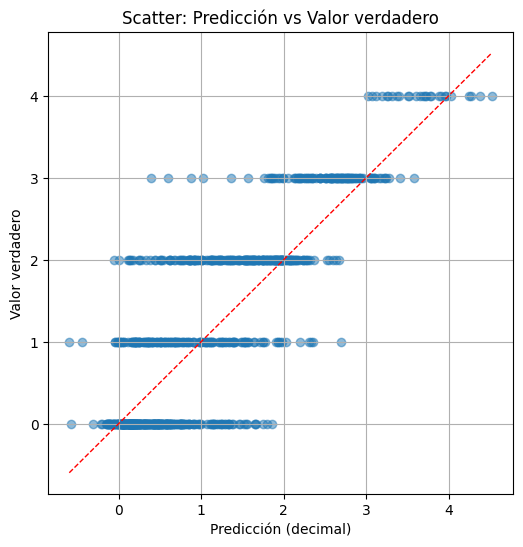

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

        KL 0     0.7568    0.6829    0.7179       328
        KL 1     0.2932    0.4771    0.3632       153
        KL 2     0.6250    0.5425    0.5808       212
        KL 3     0.8077    0.5943    0.6848       106
        KL 4     0.9444    0.6296    0.7556        27
        KL 5     0.0000    0.0000    0.0000         0

    accuracy                         0.5956       826
   macro avg     0.5712    0.4877    0.5170       826
weighted avg     0.6497    0.5956    0.6140       826



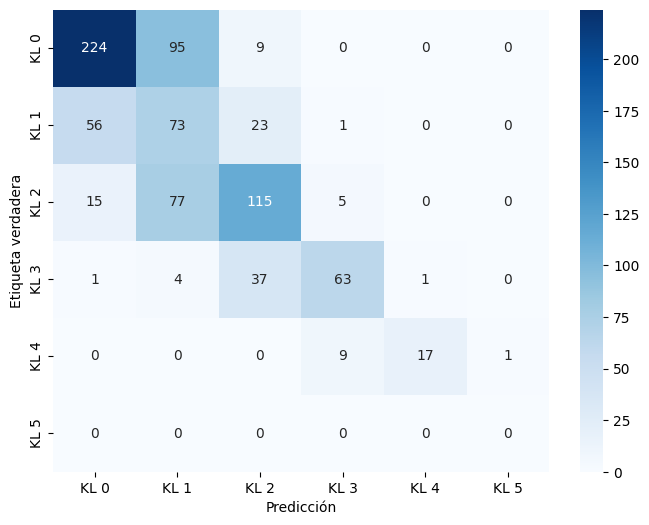

26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step
Mean Absolute Error (MAE): 0.5152



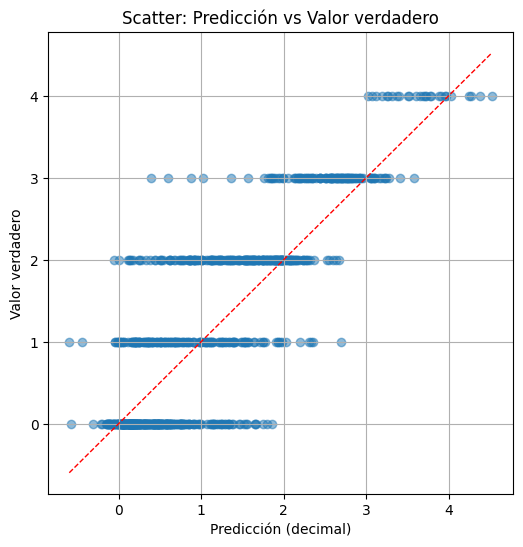

              precision    recall  f1-score   support

        KL 0     0.7568    0.6829    0.7179       328
        KL 1     0.2932    0.4771    0.3632       153
        KL 2     0.6250    0.5425    0.5808       212
        KL 3     0.8077    0.5943    0.6848       106
        KL 4     0.9444    0.6296    0.7556        27
        KL 5     0.0000    0.0000    0.0000         0

    accuracy                         0.5956       826
   macro avg     0.5712    0.4877    0.5170       826
weighted avg     0.6497    0.5956    0.6140       826



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


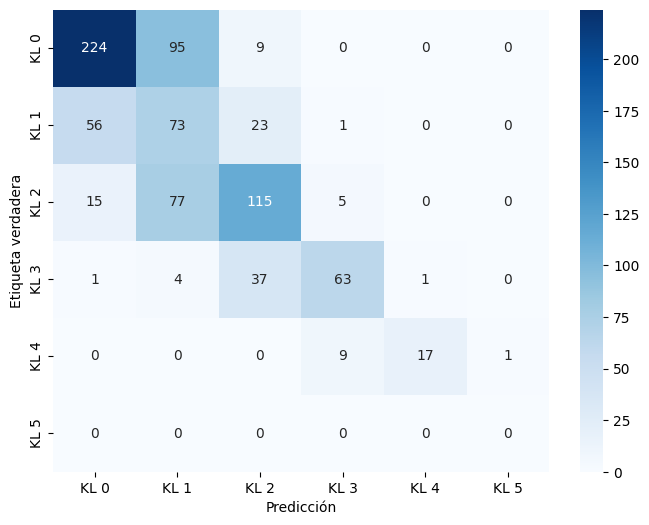

In [17]:
# 0 y 1 regressión
# Tarea 2

regression = True
tarea = 0
frozen=False
finetuning=True
batch_size = 32
num_classes = 5
if regression:
    num_classes = 1
elif tarea == 1:
    num_classes = 3
elif tarea > 1:
    num_classes = 2
model = resnet152(num_classes, regression, frozen)
entrenar_tarea(regression=regression, tarea=tarea, frozen=frozen, finetuning = finetuning, batch_size=32, model=model, verbose=0)

Found 5778 validated image filenames.
Found 826 validated image filenames.

🚀 Iniciando entrenamiento para la tarea: 1
------------------------------------------------------------
   • Tipo de tarea     : Regresión
   • Pesos congelados  : No
   • Fine-tuning activo: Sí



/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_loss improved from inf to 88.26093, saving model to best_model.keras

Epoch 2: val_loss improved from 88.26093 to 0.25072, saving model to best_model.keras

Epoch 3: val_loss improved from 0.25072 to 0.24947, saving model to best_model.keras

Epoch 4: val_loss improved from 0.24947 to 0.22001, saving model to best_model.keras

Epoch 5: val_loss did not improve from 0.22001

Epoch 6: val_loss did not improve from 0.22001

Epoch 7: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 7: val_loss did not improve from 0.22001

Epoch 8: val_loss did not improve from 0.22001

Epoch 9: val_loss did not improve from 0.22001

Epoch 10: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 10: val_loss did not improve from 0.22001

Epoch 11: val_loss did not improve from 0.22001

Epoch 12: val_loss did not improve from 0.22001

Epoch 13: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.

Epoch 13: val_loss did not improve fr

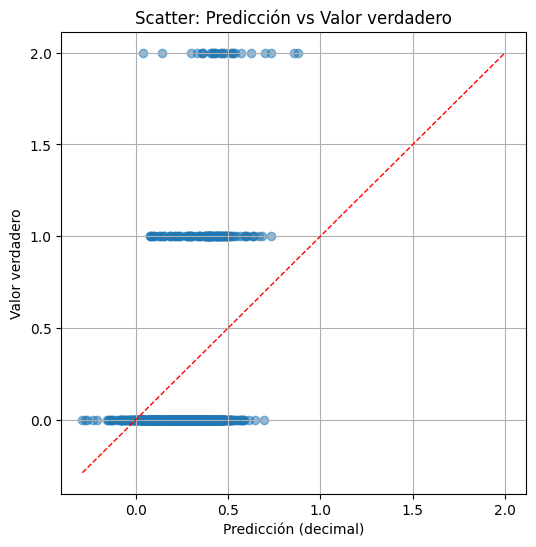

              precision    recall  f1-score   support

        KL 0     0.8630    0.9639    0.9107       693
        KL 1     0.3269    0.1604    0.2152       106
        KL 2     0.0000    0.0000    0.0000        27

    accuracy                         0.8293       826
   macro avg     0.3967    0.3748    0.3753       826
weighted avg     0.7660    0.8293    0.7917       826



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


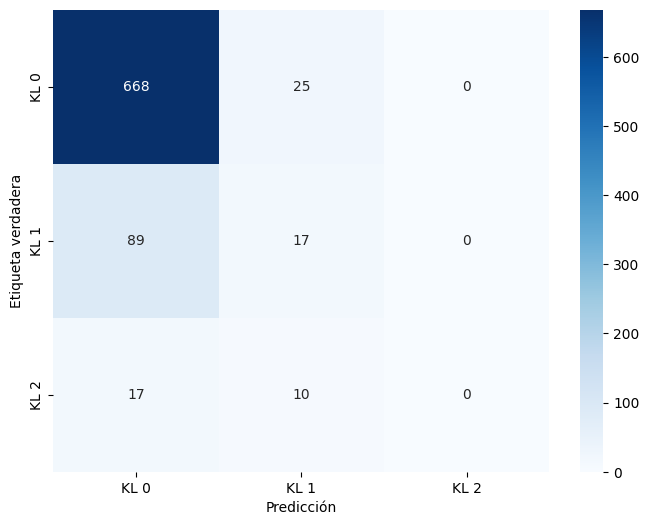

26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step
Mean Absolute Error (MAE): 0.3423



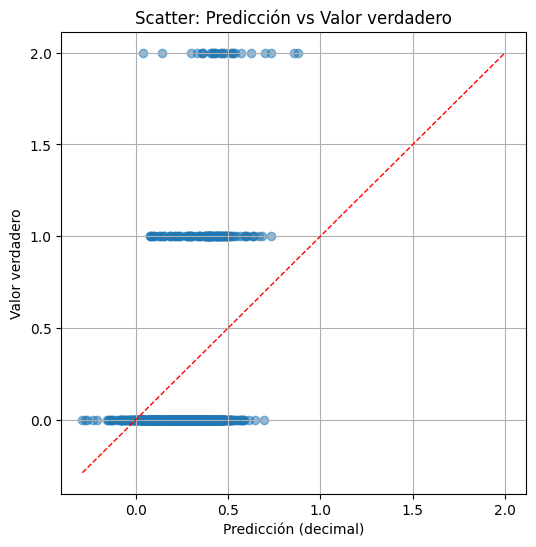

              precision    recall  f1-score   support

        KL 0     0.8630    0.9639    0.9107       693
        KL 1     0.3269    0.1604    0.2152       106
        KL 2     0.0000    0.0000    0.0000        27

    accuracy                         0.8293       826
   macro avg     0.3967    0.3748    0.3753       826
weighted avg     0.7660    0.8293    0.7917       826



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


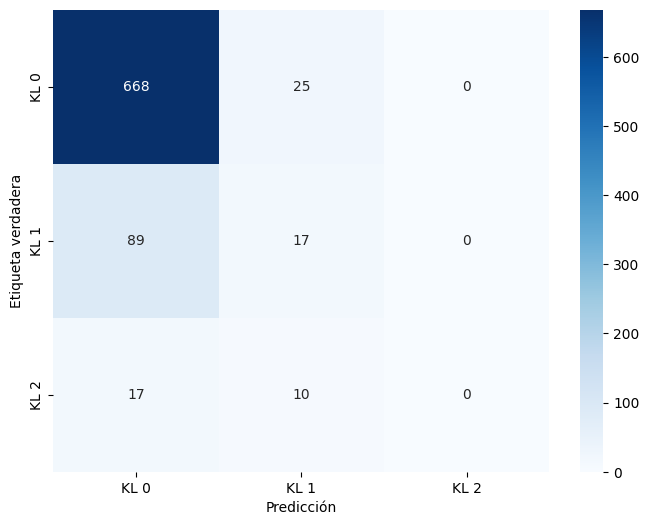

In [18]:
# 0 y 1 regressión
# Tarea 2

regression = True
tarea = 1
frozen=False
finetuning=True
batch_size = 32
num_classes = 5
if regression:
    num_classes = 1
elif tarea == 1:
    num_classes = 3
elif tarea > 1:
    num_classes = 2
model = resnet152(num_classes, regression, frozen)
entrenar_tarea(regression=regression, tarea=tarea, frozen=frozen, finetuning = finetuning, batch_size=32, model=model, verbose=0)

Found 3332 validated image filenames belonging to 2 classes.
Found 481 validated image filenames belonging to 2 classes.

🚀 Iniciando entrenamiento para la tarea: 2
------------------------------------------------------------
   • Tipo de tarea     : Clasificación
   • Pesos congelados  : No
   • Fine-tuning activo: Sí



/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_accuracy improved from -inf to 0.68191, saving model to best_model.keras

Epoch 2: val_accuracy did not improve from 0.68191

Epoch 3: val_accuracy did not improve from 0.68191

Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 4: val_accuracy did not improve from 0.68191

Epoch 5: val_accuracy did not improve from 0.68191

Epoch 6: val_accuracy did not improve from 0.68191

Epoch 7: val_accuracy did not improve from 0.68191

Epoch 8: val_accuracy did not improve from 0.68191

Epoch 9: val_accuracy did not improve from 0.68191

Epoch 10: val_accuracy did not improve from 0.68191

Epoch 11: val_accuracy did not improve from 0.68191

Epoch 12: val_accuracy improved from 0.68191 to 0.68399, saving model to best_model.keras

Epoch 13: val_accuracy did not improve from 0.68399

Epoch 14: val_accuracy did not improve from 0.68399

Epoch 15: val_accuracy did not improve from 0.68399

Epoch 16: val_accuracy did not improve from 0.68399

Epoch 17: 

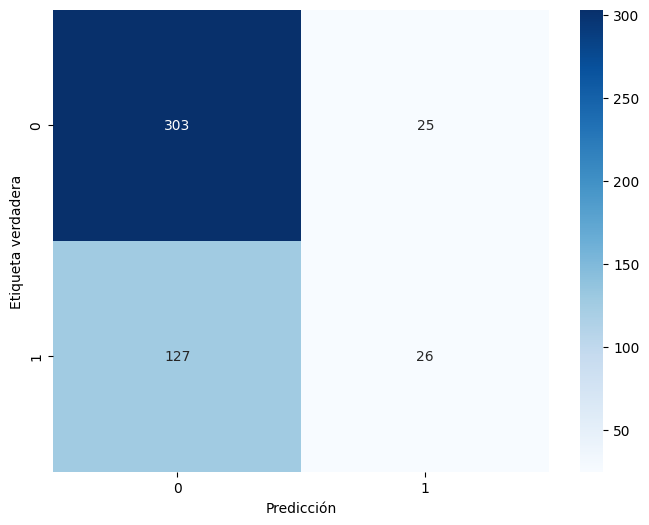

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step
              precision    recall  f1-score   support

           0     0.7207    0.8811    0.7929       328
           1     0.5125    0.2680    0.3519       153

    accuracy                         0.6861       481
   macro avg     0.6166    0.5745    0.5724       481
weighted avg     0.6545    0.6861    0.6526       481



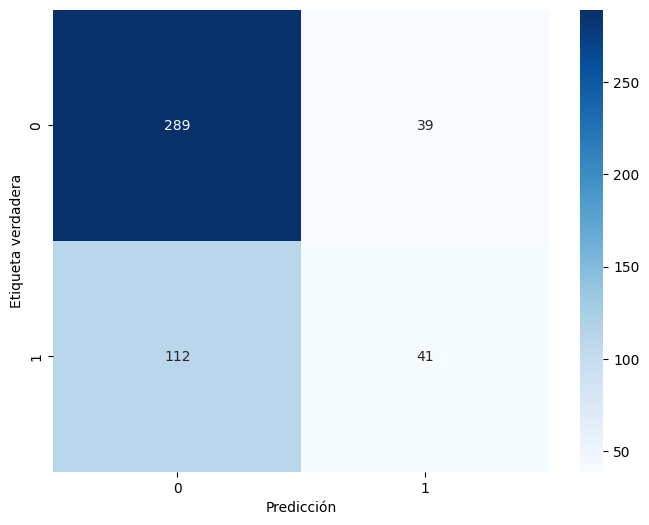

In [19]:
# 0 y 1 regressión
# Tarea 2

regression = False
tarea = 2
frozen=False
finetuning=True
batch_size = 32
num_classes = 5
if regression:
    num_classes = 1
elif tarea == 1:
    num_classes = 3
elif tarea > 1:
    num_classes = 2
model = resnet152(num_classes, regression, frozen)
entrenar_tarea(regression=regression, tarea=tarea, frozen=frozen, finetuning = finetuning, batch_size=32, model=model, verbose=0)

### Codigo util?

# Anterior

## Exploración del dataset de artrosis de rodilla

- **Total de imágenes:** 9 786

| Partición      | Imágenes | Porcentaje |
|---------------|---------:|-----------:|
| **Train**      | 5 778    | 59.04 %    |
| **Validation** |   826    |  8.44 %    |
| **Test**       | 1 656    | 16.92 %    |
| **AutoTest**   | 1 526    | 15.59 %    |


### Distribución de clases en `Train`

|  Clase  | Índice | Imágenes | Porcentaje |
|---------|-------:|---------:|-----------:|
| Sin     |      0 |    2 286 |     39.56 % |
| Ligera  |      1 |    1 046 |     18.10 % |
| Leve    |      2 |    1 516 |     26.24 % |
| Moderada|      3 |      757 |     13.10 % |
| Severa  |      4 |      173 |      2.99 % |

